# Waterfall plots:

In this notebook, I used pre-determined data to create a typical waterfall plot that included the average power and spectrum over time/frequency(depending on the chart).  This is important because it keeps track of where the rfi is as compared to CHIME's main focal source which is the Sun.  The Sun is used as a main prameter due to CHIME being a fixed telescope. The Sun is used to calibrate the data taken by CHIME due to it being overall a fixed radio source which then we could use it to convert counts in time to units of Jy/sec.


In [2]:
#imports

import numpy as np
import matplotlib.pyplot as plt
import chime

#loading data from chime archive

sample_data = "/home/scratch/dbautist/CHIME_archive/2025_018"
chime.calibration.load_CHIME_data(sample_data)
chime_data, frequency, timestamps = chime.calibration.load_CHIME_data(sample_data)

print(chime_data)
print(f'bit sizes:{len(chime_data)}')

print(f"chime data:{type(chime_data)}\n frequency:{type(frequency)}\n timestamps:{type(timestamps)}")

print(f'timestamps{timestamps}')

[[16972767.64514628 16522876.72422378 17896828.81456248 ...
   3781281.32690793  3561239.99578294   946201.36686611]
 [17625351.96273997 15599255.54499675 15183475.13864138 ...
   3594519.05328758  3338687.35502378   995371.14068732]
 [15163296.43790293 16730431.34413033 16089577.90928771 ...
   3466761.38347171  2879186.21672957   903850.68505452]
 ...
 [23284437.30398133 17721346.99905585 15242611.83836535 ...
   3385119.14257679  3098687.60811211   912429.20535361]
 [20458230.10688284 16597566.54909407 16205435.60692183 ...
   3761789.10455141  3017638.64724671   870336.92133346]
 [18234476.65687509 17693070.61676088 15348037.91472175 ...
   3288795.56580792  2884369.80020616   842397.52672124]]
bit sizes:2521
chime data:<class 'numpy.ndarray'>
 frequency:<class 'numpy.ndarray'>
 timestamps:<class 'list'>
timestamps[datetime.datetime(2025, 1, 18, 4, 0, 5, 616385, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 1, 18, 4, 0, 35, 735782, tzinfo=datetime.timezone.utc), datetime.d

# Plot 1:

This is the colorful waterfall plot, created using matplotlib.pyplot to showcase the spectrum of the data over different frequency channels at different times.  The x axis being the frequencies CHIME measures at(400 to 800 MHz) and the y axis being the times during the day at which the data was processed.  The beam in the waterfall plot will be consistant throughout all days that are imported into the data as that beam is the Sun.  RFI spikes are typically tracked by noticing the infrequent spikes in spectra which unlike the sun, are not statistically well averaged

2521
chime data:<class 'numpy.ndarray'>
 frequency:<class 'numpy.ndarray'>
 timestamps:<class 'list'>
extent: [400.0, 800.0, datetime.datetime(2025, 1, 19, 1, 5, 6, 496988, tzinfo=datetime.timezone.utc), datetime.datetime(2025, 1, 18, 4, 0, 5, 616385, tzinfo=datetime.timezone.utc)]


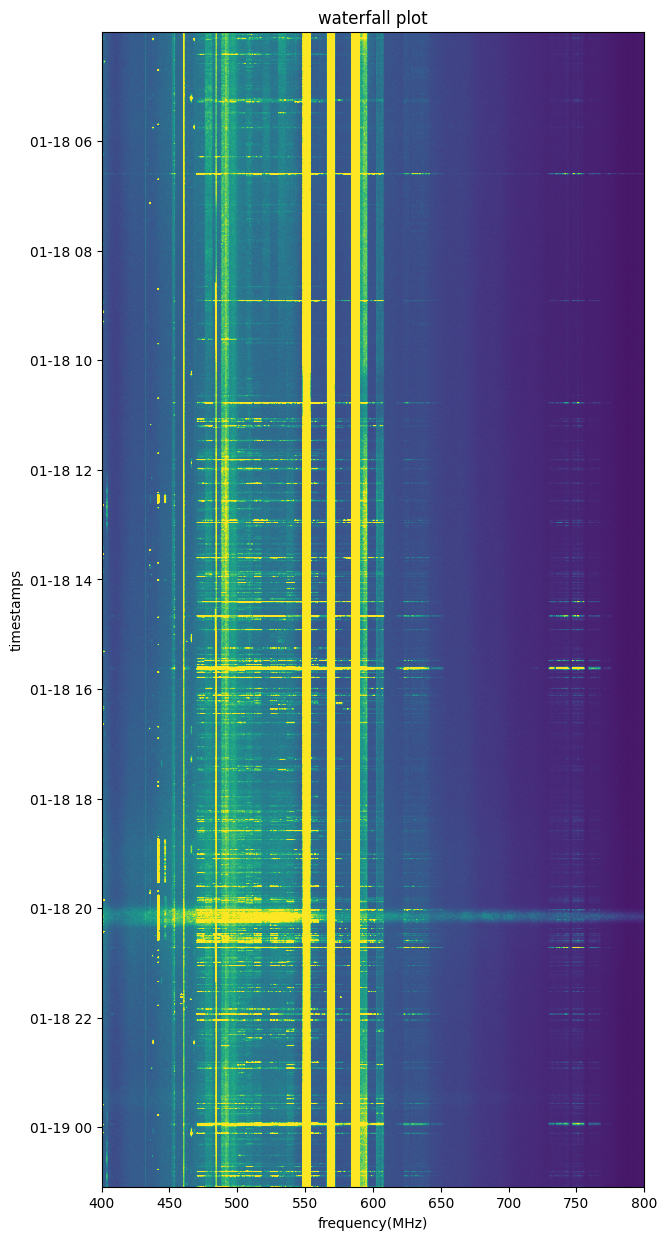

In [2]:
#imports

import numpy as np
import matplotlib.pyplot as plt
import chime

#loading data from chime archive

sample_data = "/home/scratch/dbautist/CHIME_archive/2025_018"
chime.calibration.load_CHIME_data(sample_data)
chime_data, frequency, timestamps = chime.calibration.load_CHIME_data(sample_data)

#print statements for reference 

print(len(chime_data))
print(f"chime data:{type(chime_data)}\n frequency:{type(frequency)}\n timestamps:{type(timestamps)}")

#plot fitting 

fig, ax1 = plt.subplots(figsize=(7,15))

#color values for range of a color

vmin = 0
vmax = 5e7

#labels

ax1.set_xlabel('frequency(MHz)')
ax1.set_ylabel('timestamps')
ax1.set_title('waterfall plot')

#extent:

extent = [np.round(np.min(frequency)), np.round(np.max(frequency)), max(timestamps), min(timestamps)] 

#plot display

im = ax1.imshow(chime_data, aspect="auto", extent=extent, vmin=vmin, vmax=vmax)

print(f'extent: {extent}')

2521
chime data:<class 'numpy.ndarray'>
 frequency:<class 'numpy.ndarray'>
 timestamps:<class 'list'>
time series:[2.27888616e+10 2.33764882e+10 2.28349067e+10 ... 2.33640175e+10
 2.17350593e+10 3.19746327e+10]
average spectrum:[24902537.00873651 22592659.37566617 21210309.85888665 ...
  3670934.70568227  3208742.86231203   986849.05615214]


ValueError: x and y must have same first dimension, but have shapes (1,) and (1024,)

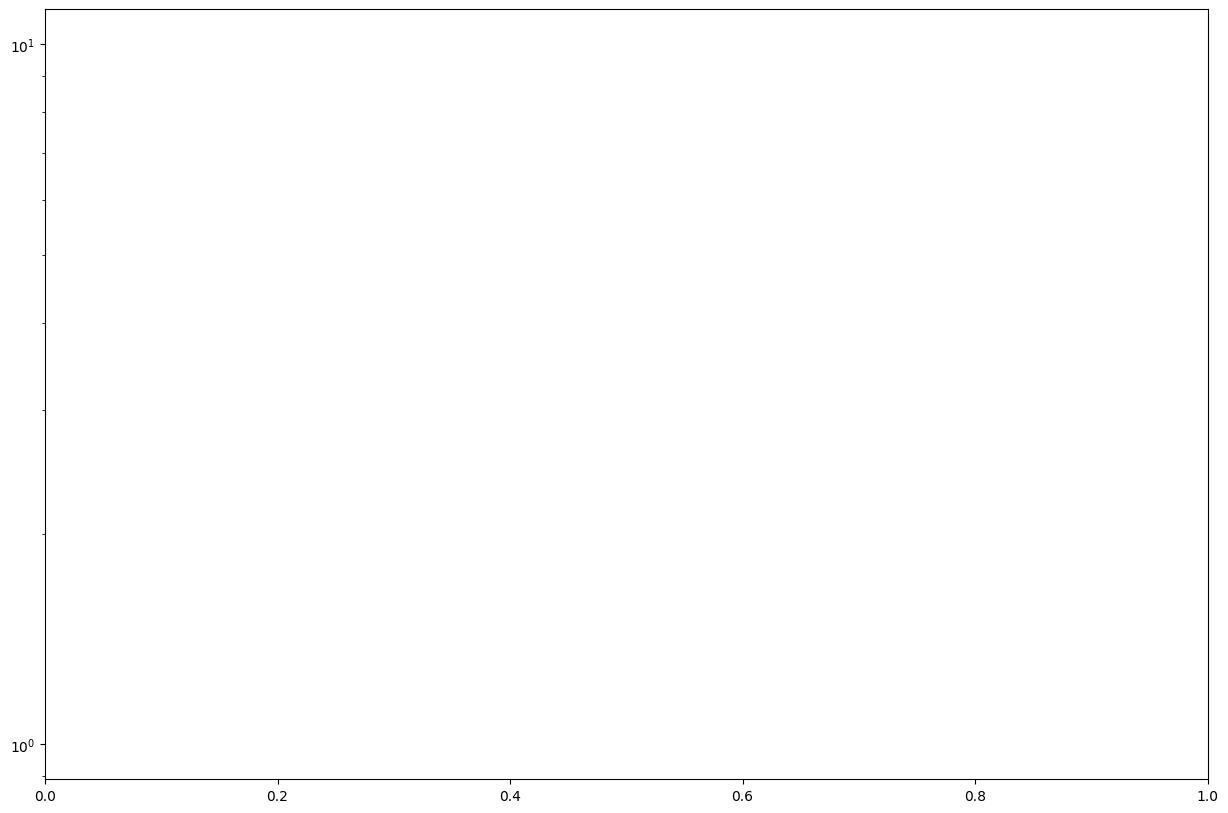

In [7]:
#averages spectrum vs.frequency plot

'''#imports

import numpy as np
import matplotlib.pyplot as plt
import chime

#loading data from chime archive

sample_data = "/home/scratch/dbautist/CHIME_archive/2025_018"
chime.calibration.load_CHIME_data(sample_data)
chime_data, frequency, timestamps = chime.calibration.load_CHIME_data(sample_data)'''

#print statements for reference 

print(len(chime_data))
print(f"chime data:{type(chime_data)}\n frequency:{type(frequency)}\n timestamps:{type(timestamps)}")

time_series = np.sum(chime_data, axis=1) #time series of the data, running across the columns
print(f"time series:{time_series}")

avg_spectrum = np.mean(chime_data, axis=0)  #average spectrum for spectrum data, running down the columns
print(f"average spectrum:{avg_spectrum}")

#plot fitting 

fig, ax2 = plt.subplots(figsize=(15,10)) #using plt.subplots

ax2.semilogy(frequency, avg_spectrum, color="blue", linewidth=1)

ax2.set_xlabel("average spectrum")
ax2.set_ylabel("timeseries")
ax2.set_title("Average spectrum vs. frequency")




Text(0, 0.5, 'counts')

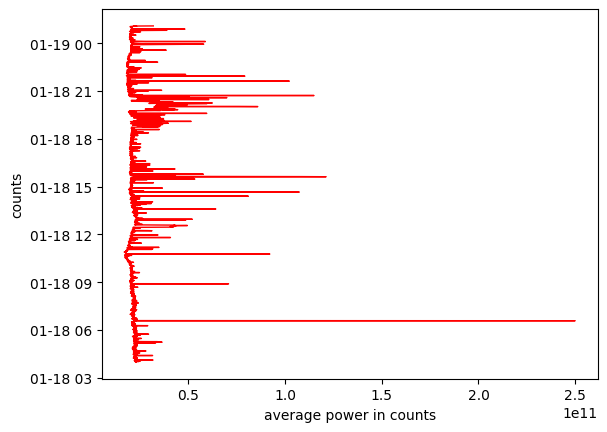

In [7]:
#average power vs. time plot:

#imports

import numpy as np
import matplotlib.pyplot as plt
import chime

#loading data from chime archive

unit = 'counts'
vmin = 0
vmax = 5e7

#specify calculations:

time_series = np.sum(chime_data, axis=1)


sample_data = "/home/scratch/dbautist/CHIME_archive/2025_018"
chime.calibration.load_CHIME_data(sample_data)
chime_data, frequency, timestamps = chime.calibration.load_CHIME_data(sample_data)


#plot labeling:

fig, ax4 = plt.subplots()


ax4.plot(time_series, timestamps, color='red', linewidth=1)
ax4.set_xlabel("average power in counts")
ax4.set_ylabel("counts")





# Large plot:

This plot is the main plot NRAO Spectrum Management uses to showcase Spectrum from a whole day with CHIME data.  These plots representing a waterfall plot, average power in counts, and average frequency vs. spectrum(the plot in blue).  For each new day this can be used to denote and keep track of random spikes in the Spectrum which are most likely RFI. 

Text(0.5, 0, 'power\n[counts]')

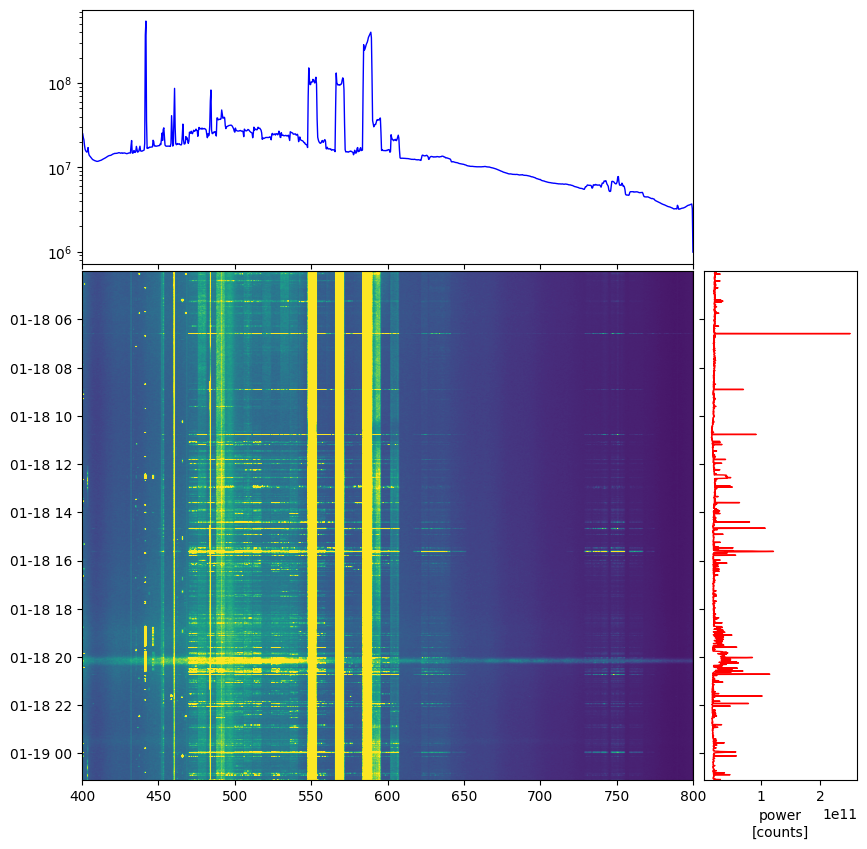

In [ ]:
#putting it all together:

fig = plt.figure(figsize=(10,10))  #making the overall figure size
gs = fig.add_gridspec(2,2, hspace=0.02, wspace=0.03, width_ratios=[4,1], height_ratios=[2,4])
#setting and dividing graphs
[ax2, ax3], [ax1, ax4] = gs.subplots(sharex="col", sharey="row") #splitting up the graphs
'''ax1 = waterfall plot
    ax2 = avg. power vs. time
    ax3 = the invisable one
    ax4 = avg. power per channel'''


ax2.semilogy(frequency, avg_spectrum, color="blue", linewidth=1)

  
im = ax1.imshow(chime_data, aspect="auto", extent=extent, vmin=vmin, vmax=vmax)
ax3.set_visible(not ax3)  #sets ax3 to be invisable 
#still need to figure out ax4
ax4.plot(time_series, timestamps, color='red', linewidth=1)
ax4.set_xlabel(f'power\n[{unit}]')

plt.savefig('Detailed waterfall plot')
